In [1]:
import pandas as pd

df = pd.read_csv("../Data/german_credit_risk.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (1000, 11)

Columns:
['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB

Missing Values:
Unnamed: 0            0
Age                   0
Sex                   0
Job       

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [5]:
risk_percentage = df["Risk"].value_counts(normalize=True) * 100
risk_percentage

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

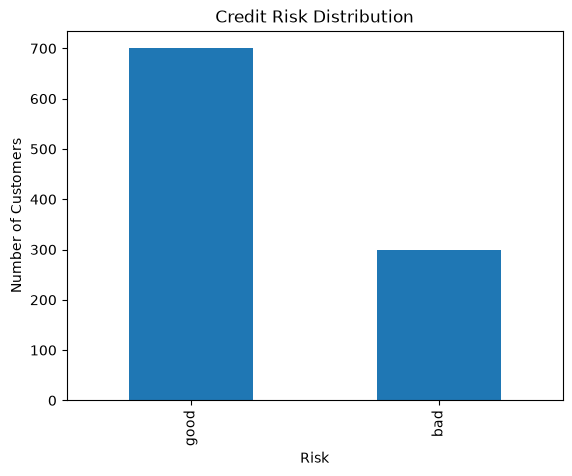

In [6]:
import matplotlib.pyplot as plt

df["Risk"].value_counts().plot(kind="bar")

plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Number of Customers")
plt.show()

In [7]:
df.groupby("Risk")["Credit amount"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Risk,,,,
bad,3938.126667,2574.5,433,18424
good,2985.457143,2244.0,250,15857


In [8]:
df.groupby("Risk")["Duration"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Risk,,,,
bad,24.860000,24.0,6,72
good,19.207143,18.0,4,60


In [9]:
df.groupby("Risk")["Age"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Risk,,,,
bad,33.963333,31.0,19,74
good,36.224286,34.0,19,75


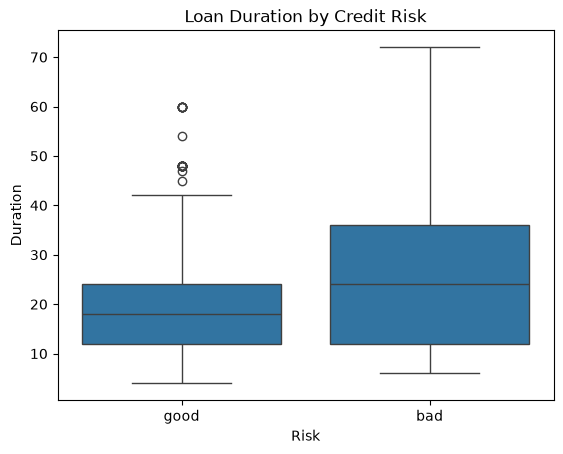

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="Risk", y="Duration")

plt.title("Loan Duration by Credit Risk")
plt.xlabel("Risk")
plt.ylabel("Duration")
plt.show()

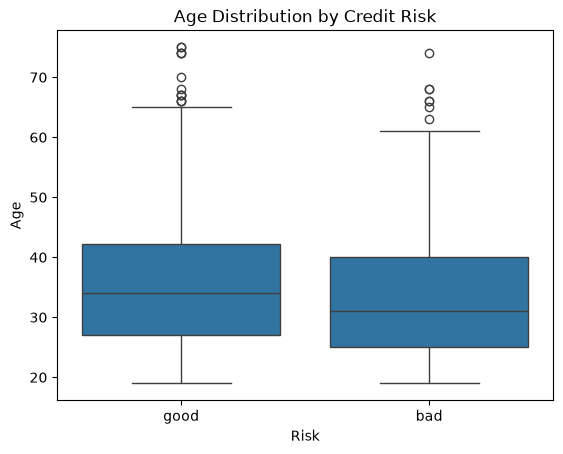

In [12]:
sns.boxplot(data=df, x="Risk", y="Age")

plt.title("Age Distribution by Credit Risk")
plt.xlabel("Risk")
plt.ylabel("Age")
plt.show()

In [13]:
job_risk = pd.crosstab(df["Job"], df["Risk"])

job_risk

Risk,bad,good
Job,,
0,7,15
1,56,144
2,186,444
3,51,97


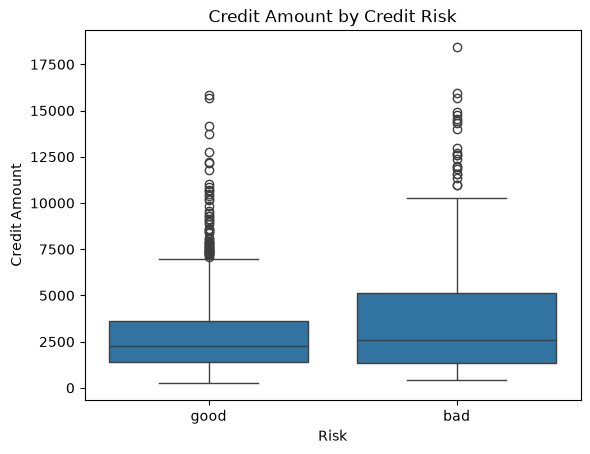

In [11]:
sns.boxplot(data=df, x="Risk", y="Credit amount")

plt.title("Credit Amount by Credit Risk")
plt.xlabel("Risk")
plt.ylabel("Credit Amount")
plt.show()

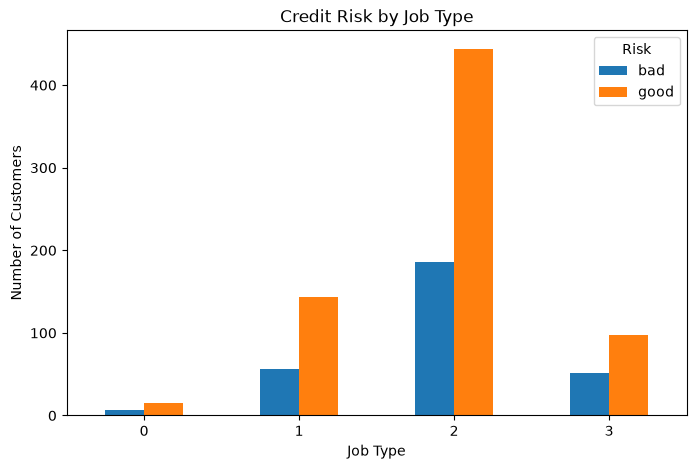

In [14]:
job_risk.plot(kind="bar", figsize=(8, 5))

plt.title("Credit Risk by Job Type")
plt.xlabel("Job Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Risk")
plt.show()

In [15]:
housing_risk = pd.crosstab(df["Housing"], df["Risk"])

housing_risk

Risk,bad,good
Housing,,
free,44,64
own,186,527
rent,70,109


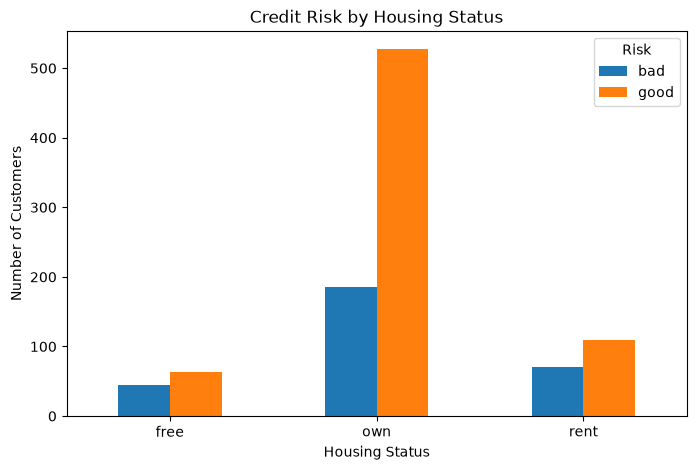

In [16]:
housing_risk.plot(kind="bar", figsize=(8, 5))

plt.title("Credit Risk by Housing Status")
plt.xlabel("Housing Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Risk")
plt.show()

In [18]:
saving_risk = pd.crosstab(df["Saving accounts"], df["Risk"])

saving_risk

Risk,bad,good
Saving accounts,,
little,217,386
moderate,34,69
quite rich,11,52
rich,6,42


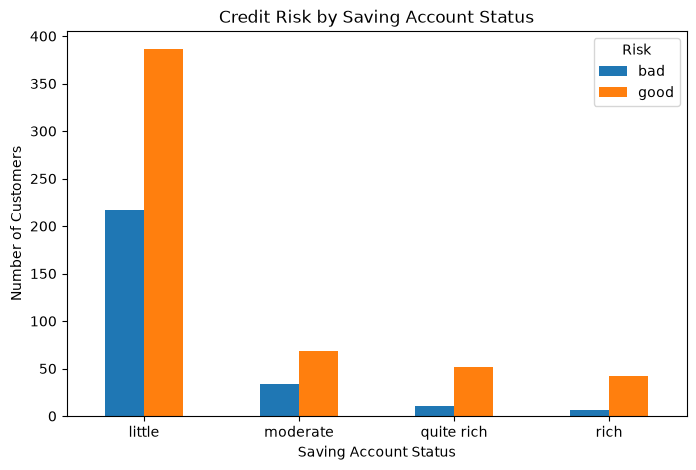

In [19]:
saving_risk.plot(kind="bar", figsize=(8, 5))

plt.title("Credit Risk by Saving Account Status")
plt.xlabel("Saving Account Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Risk")
plt.show()

In [20]:
checking_risk = pd.crosstab(df["Checking account"], df["Risk"])

checking_risk

Risk,bad,good
Checking account,,
little,135,139
moderate,105,164
rich,14,49


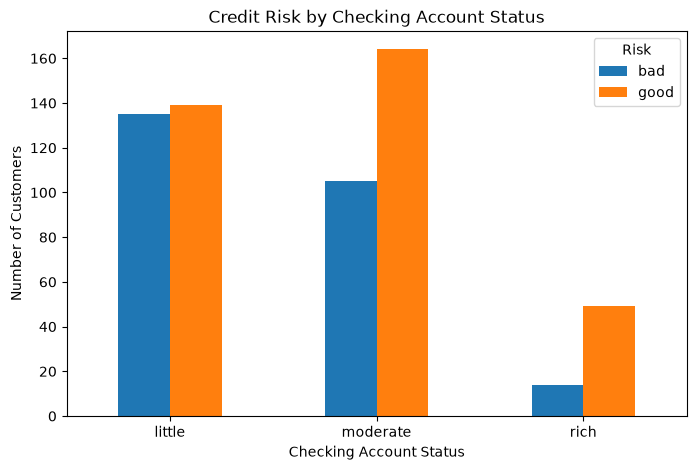

In [21]:
checking_risk.plot(kind="bar", figsize=(8, 5))

plt.title("Credit Risk by Checking Account Status")
plt.xlabel("Checking Account Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Risk")
plt.show()

In [22]:
housing_risk_pct = pd.crosstab(
    df["Housing"],
    df["Risk"],
    normalize="index"
) * 100

housing_risk_pct

Risk,bad,good
Housing,,
free,40.740741,59.259259
own,26.086957,73.913043
rent,39.106145,60.893855


In [23]:
saving_risk_pct = pd.crosstab(
    df["Saving accounts"],
    df["Risk"],
    normalize="index"
) * 100

saving_risk_pct

Risk,bad,good
Saving accounts,,
little,35.986733,64.013267
moderate,33.009709,66.990291
quite rich,17.460317,82.539683
rich,12.500000,87.500000


In [24]:
checking_risk_pct = pd.crosstab(
    df["Checking account"],
    df["Risk"],
    normalize="index"
) * 100

checking_risk_pct

Risk,bad,good
Checking account,,
little,49.270073,50.729927
moderate,39.033457,60.966543
rich,22.222222,77.777778


In [25]:
numeric_cols = df.select_dtypes(include="number")

correlation = numeric_cols.corr()

correlation

,Unnamed: 0,Age,Job,Credit amount,Duration
Unnamed: 0,1.000000,-0.010096,-0.027345,0.013488,0.030788
Age,-0.010096,1.000000,0.015673,0.032716,-0.036136
Job,-0.027345,0.015673,1.000000,0.285385,0.210910
Credit amount,0.013488,0.032716,0.285385,1.000000,0.624984
Duration,0.030788,-0.036136,0.210910,0.624984,1.000000


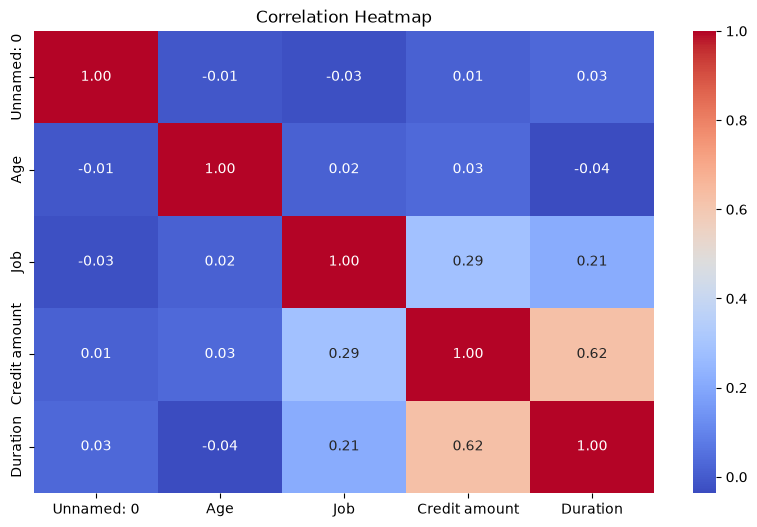

In [26]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [29]:
risk_summary = df.groupby("Risk")[["Credit amount", "Duration", "Age"]].mean()

risk_summary

,Credit amount,Duration,Age
Risk,,,
bad,3938.126667,24.860000,33.963333
good,2985.457143,19.207143,36.224286


## Business Insights

- Credit amount differs between Good and Bad credit risk groups.
- Loan duration shows differences across credit risk categories.
- Age varies across different credit risk groups.
- Housing status shows different Good and Bad risk distributions.
- Saving and checking account status are useful factors for understanding credit risk.
- Job categories also show variation in credit risk.